### #9

Kaggle competition: [\[link\]](https://www.kaggle.com/competitions/playground-series-s5e9/)

Entry by Robin R.P.M. Kras

robkras.com

### ⭐ 1. Introduction & Overview


Your Goal: The goal of this competition is to predict a song's beats-per-minute.

### 🔹 2. Import Libraries & Set Up


In [3]:
# Import standard data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import StackingRegressor, RandomForestRegressor

from utils import *
from utils_pipeline import *

# Import gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Settings for better visuals and to suppress warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# For reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Helper function for measuring model performance
def rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

DATASET OVERVIEW

Shape: (524164, 11)
Numerical columns: 11
Categorical columns: 0

DATA TYPES
id                             int64
RhythmScore                  float64
AudioLoudness                float64
VocalContent                 float64
AcousticQuality              float64
InstrumentalScore            float64
LivePerformanceLikelihood    float64
MoodScore                    float64
TrackDurationMs              float64
Energy                       float64
BeatsPerMinute               float64
dtype: object

MISSING VALUES
No missing values found!

BASIC STATISTICS
                  id    RhythmScore  ...         Energy  BeatsPerMinute
count  524164.000000  524164.000000  ...  524164.000000   524164.000000
mean   262081.500000       0.632843  ...       0.500923      119.034899
std    151313.257587       0.156899  ...       0.289952       26.468077
min         0.000000       0.076900  ...       0.000067       46.718000
25%    131040.750000       0.515850  ...       0.254933      101.

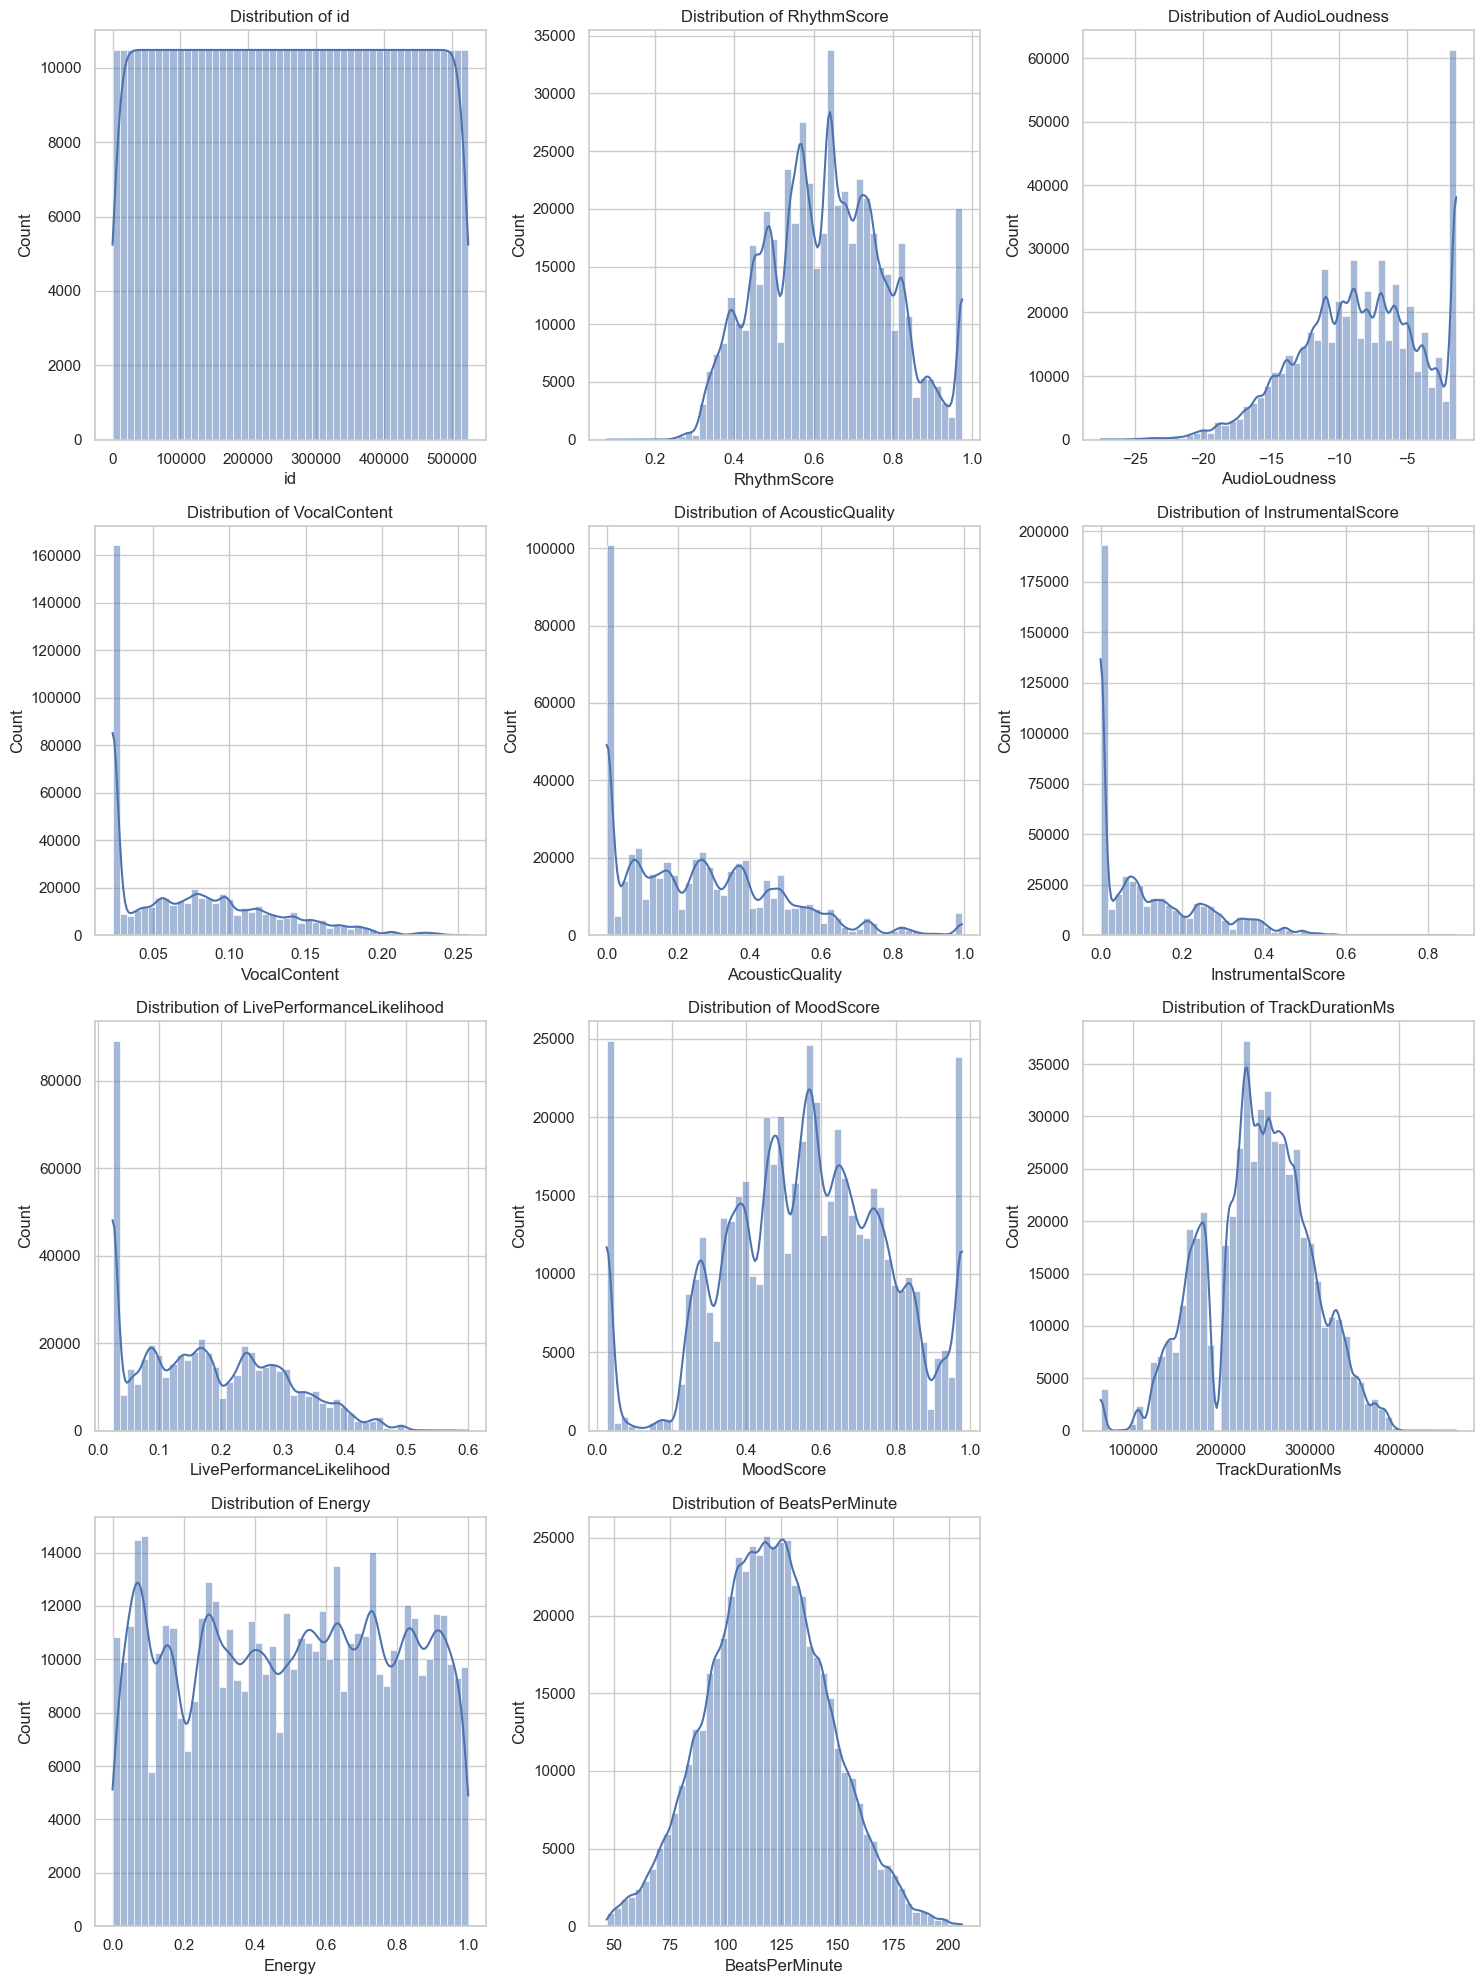


Correlation Analysis:


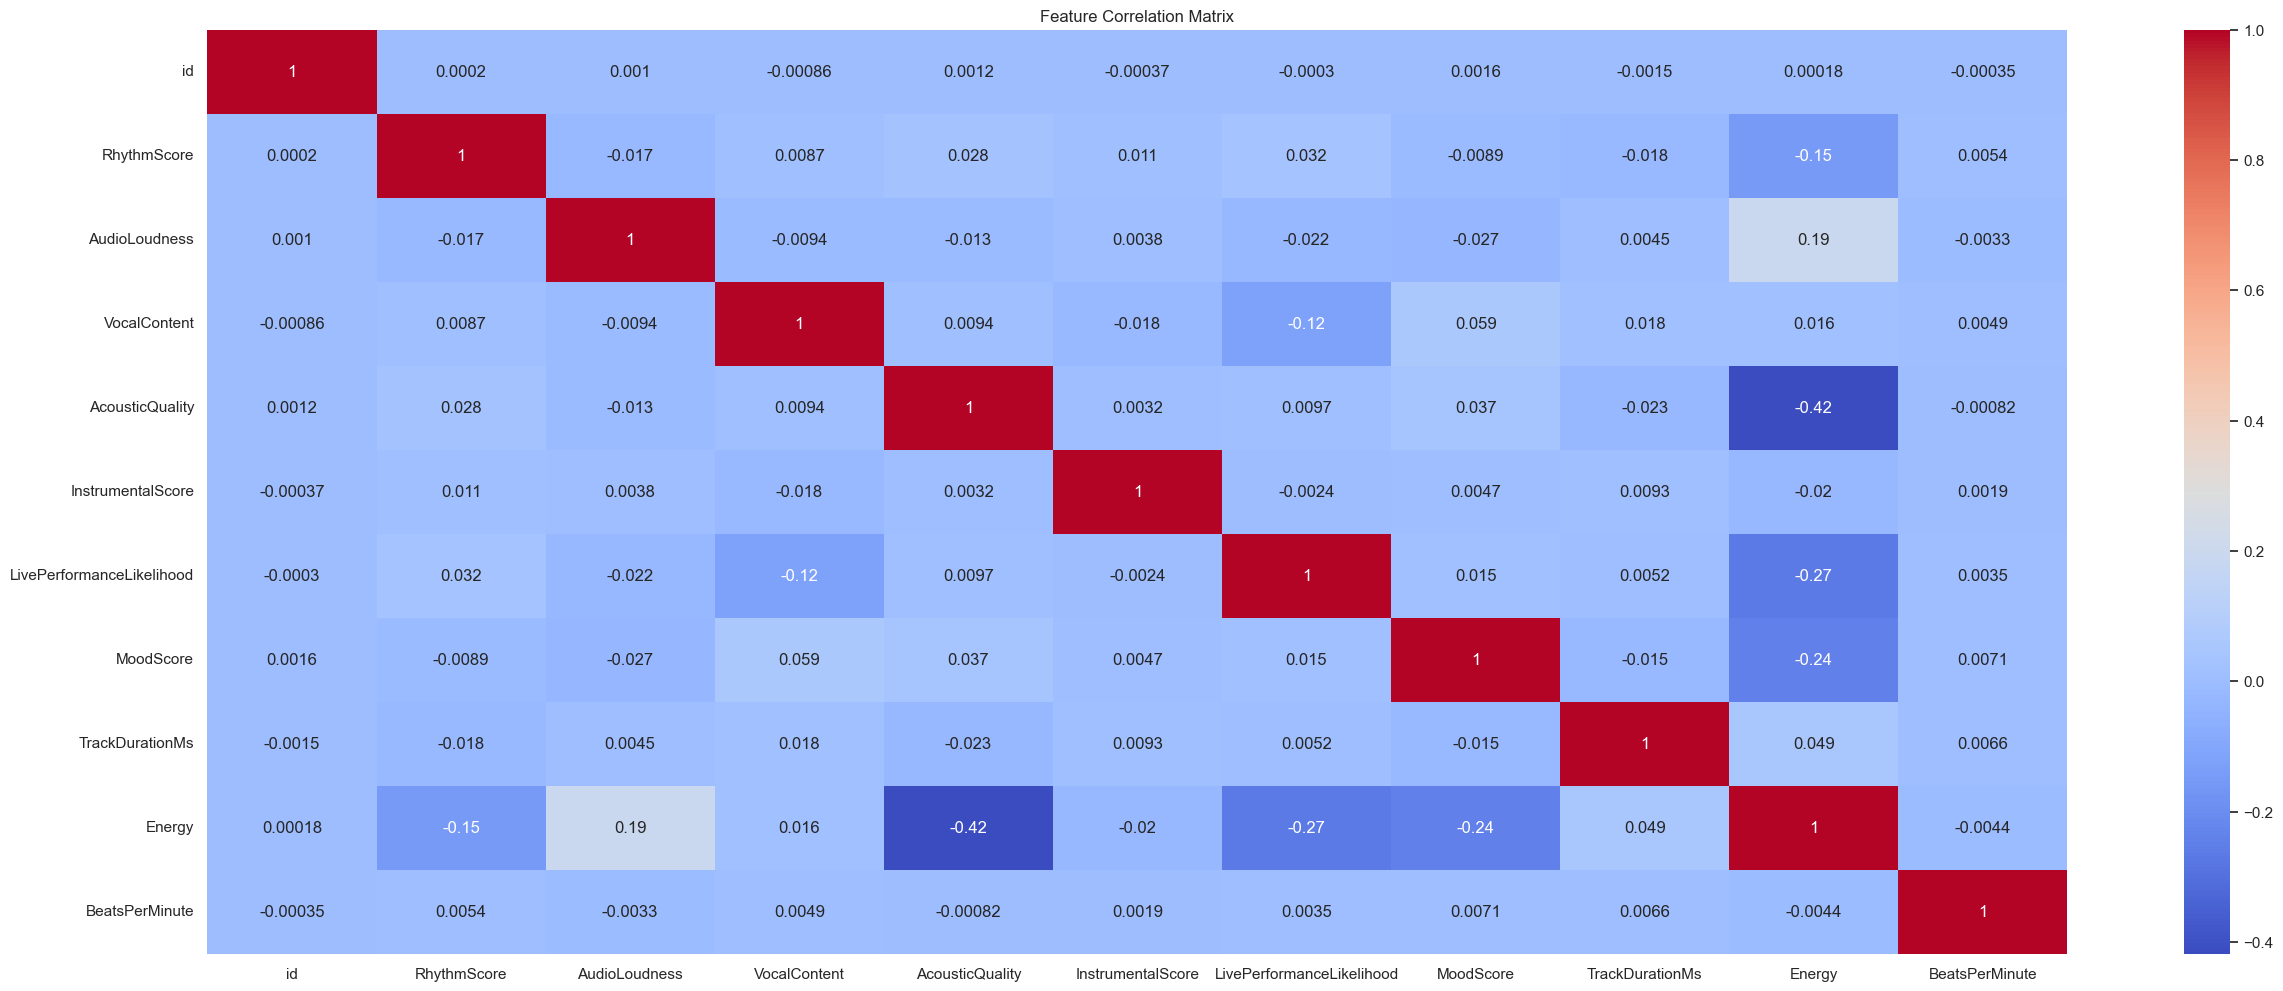

Highly correlated feature pairs (above threshold):
Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


In [6]:
eda = EDAIPipeline(train)
eda_results = eda.run_full_eda()

In [7]:
# Feature Engineering only
fe = FeatureEngineeringPipeline(train)
fe.create_combinations().remove_high_correlation(0.95)
engineered_df = fe.get_engineered_data()

Creating combinations for 11 features...
Created 55 new combination features
Removing 37 highly correlated features (threshold: 0.95)

Final dataset shape: (524164, 29)
New features created: 55


### 🔹 3. Data Exploration


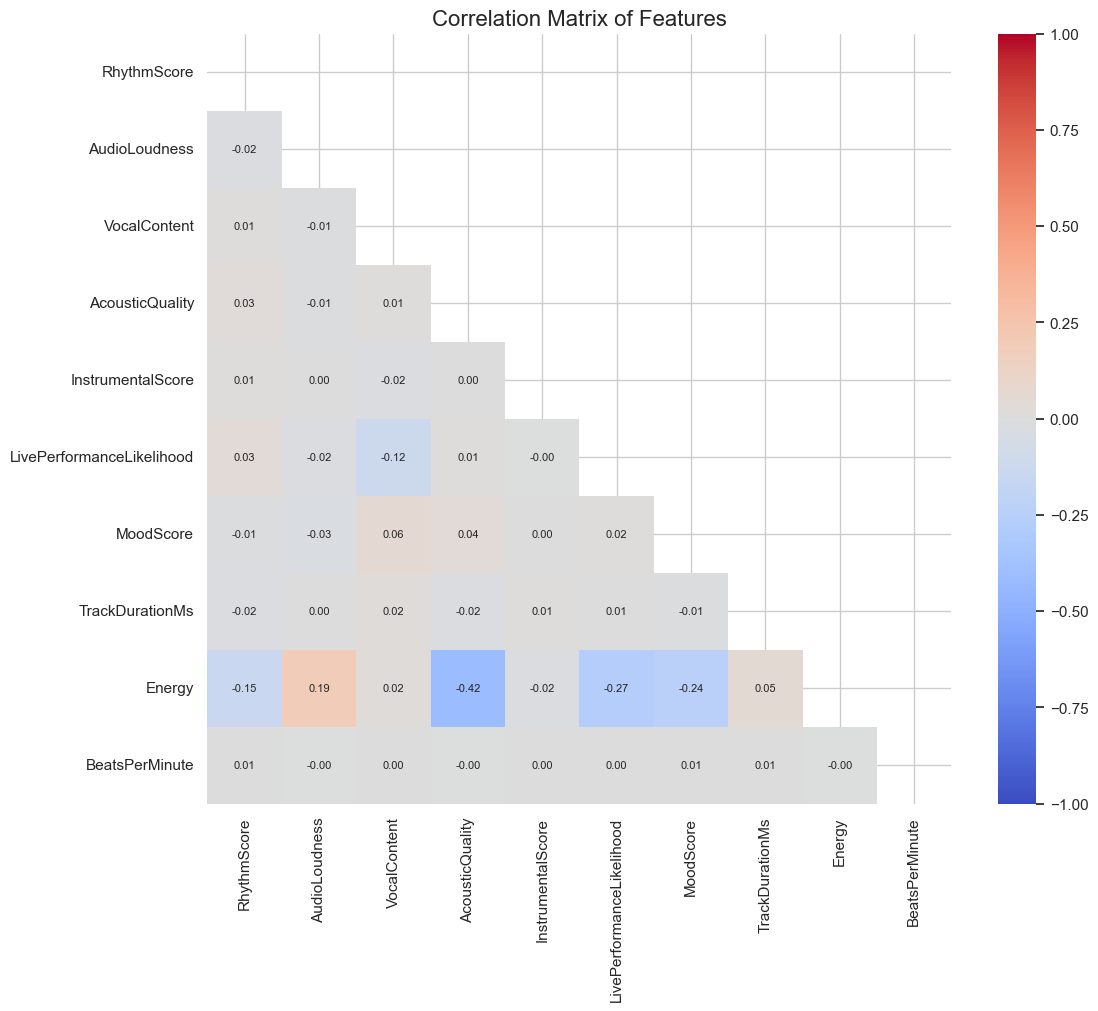

Feature Correlation with BPM:
BeatsPerMinute               1.000000
MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64


In [56]:
# Create a correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = train.drop('id', axis=1, errors='ignore').corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

# Sort features by correlation with target
target_correlation = correlation_matrix['BeatsPerMinute'].sort_values(ascending=False)
print("Feature Correlation with BPM:")
print(target_correlation)

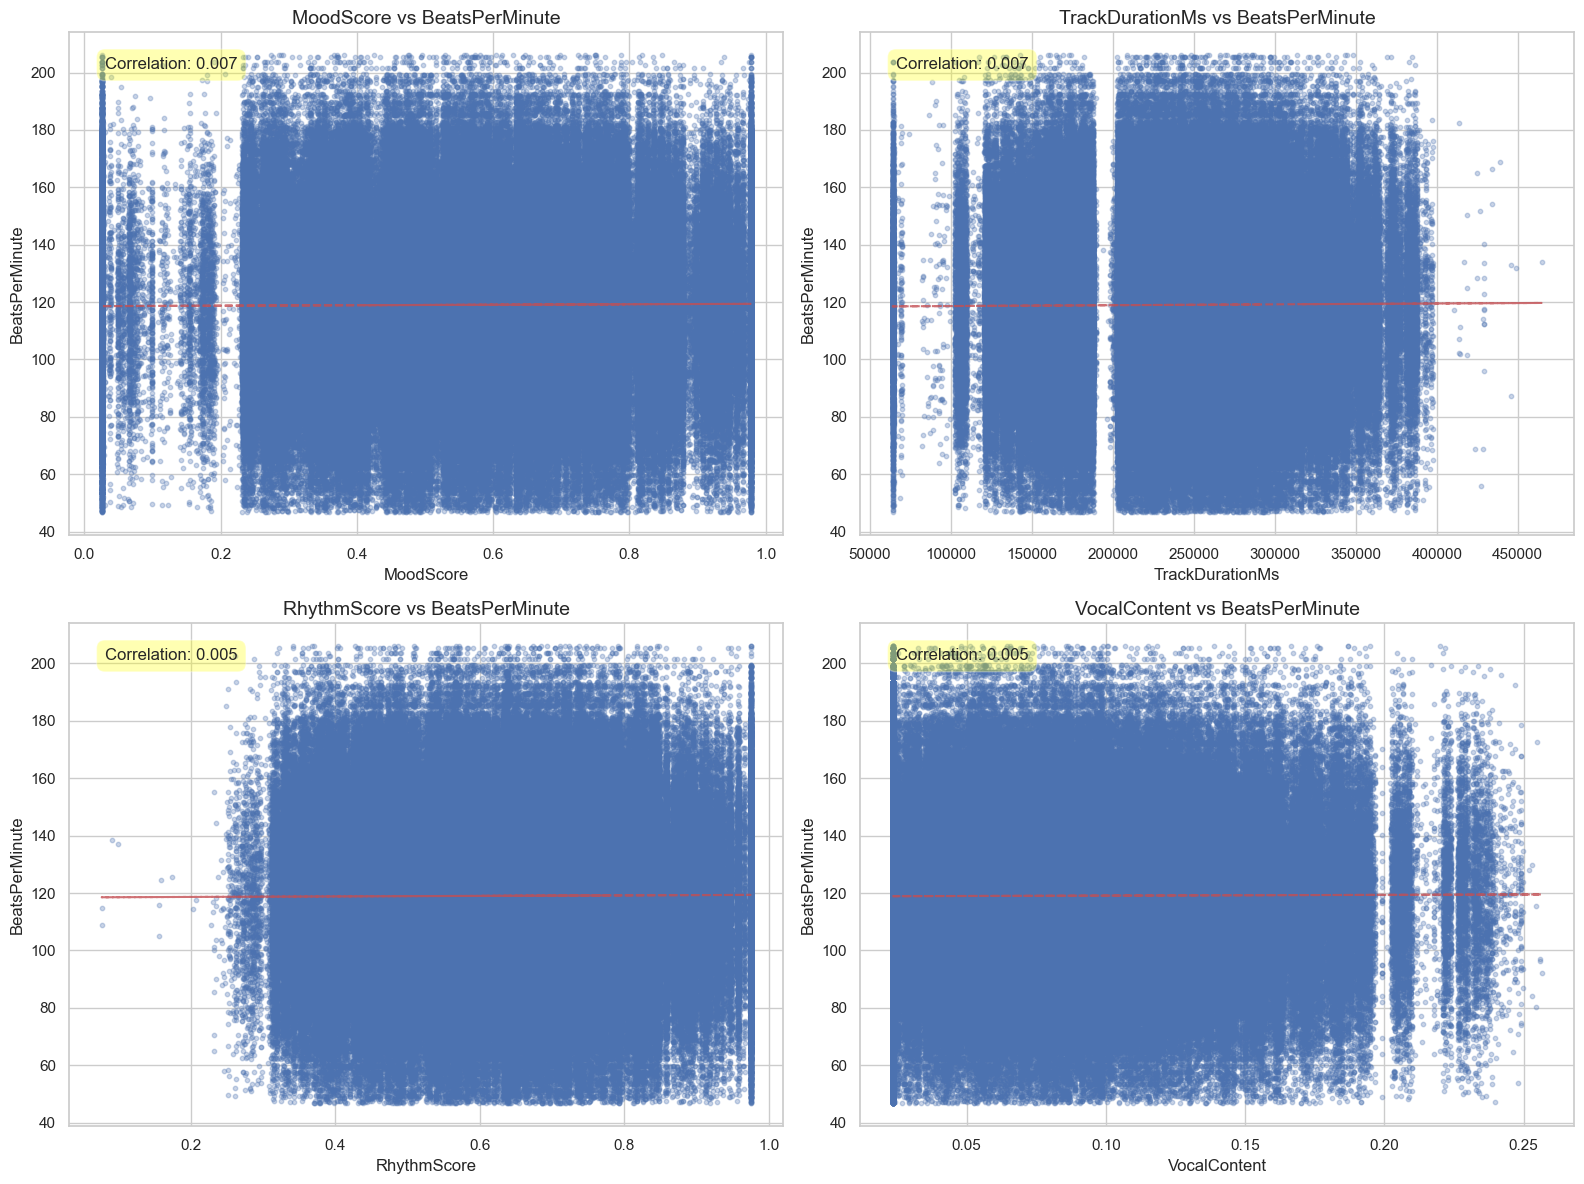

In [57]:
# Get top 4 features correlated with target
top_features = target_correlation.index[1:5]  # Excluding BeatsPerMinute itself

# Create scatter plots for each top feature vs target
plt.figure(figsize=(16, 12))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    plt.scatter(train[feature], train['BeatsPerMinute'], alpha=0.3, s=10)
    plt.title(f'{feature} vs BeatsPerMinute', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('BeatsPerMinute', fontsize=12)
    
    # Add trend line
    z = np.polyfit(train[feature], train['BeatsPerMinute'], 1)
    p = np.poly1d(z)
    plt.plot(train[feature], p(train[feature]), "r--", alpha=0.8)
    
    # Add correlation coefficient to plot
    corr = train[feature].corr(train['BeatsPerMinute'])
    plt.annotate(f'Correlation: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                 fontsize=12, ha='left', va='top', 
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

### 🔹 4. Feature Engineering

In [58]:
def engineer_features(df):
    """Create engineered features for the dataset
    
    Args:
        df: DataFrame containing the original features
        
    Returns:
        DataFrame with additional engineered features
    """
    # Create a copy to avoid modifying the original dataframe
    df_new = df.copy()
    
    # 1. Rhythm-based features - BPM is directly related to rhythm
    df_new['Rhythm_Energy'] = df_new['RhythmScore'] * df_new['Energy']
    df_new['Rhythm_Loudness'] = df_new['RhythmScore'] * df_new['AudioLoudness']
    
    # 2. Duration-related features - longer tracks might have different BPM patterns
    df_new['Duration_Minutes'] = df_new['TrackDurationMs'] / 60000  # Convert to minutes
    df_new['Duration_Energy_Ratio'] = df_new['TrackDurationMs'] / (df_new['Energy'] * 10000 + 1)  # Scaled for numerical stability
    
    # 3. Non-linear transformations - capture more complex relationships
    df_new['RhythmScore_Squared'] = df_new['RhythmScore'] ** 2
    df_new['Energy_Squared'] = df_new['Energy'] ** 2
    df_new['Log_Duration'] = np.log1p(df_new['TrackDurationMs'])  # log(1+x) to handle zeros
    
    # 4. Musical character features - representing the "feel" of the song
    df_new['Acoustic_Instrumental_Ratio'] = df_new['AcousticQuality'] / (df_new['InstrumentalScore'] + 0.01)  # Avoid division by zero
    df_new['Vocal_Energy'] = df_new['VocalContent'] * df_new['Energy']
    
    # 5. Performance and mood interactions
    df_new['Live_Energy'] = df_new['LivePerformanceLikelihood'] * df_new['Energy']
    df_new['Mood_Rhythm'] = df_new['MoodScore'] * df_new['RhythmScore']
    
    # 6. Composite metrics
    df_new['Audio_Intensity'] = (df_new['Energy'] * np.abs(df_new['AudioLoudness'])) / 10  # Scaled for better range
    df_new['Performance_Character'] = (df_new['LivePerformanceLikelihood'] + df_new['MoodScore']) / 2
    
    # 7. Ratios that might represent musical balance
    df_new['Energy_Loudness_Ratio'] = df_new['Energy'] / (np.abs(df_new['AudioLoudness']) + 0.01)
    df_new['Rhythm_Duration_Density'] = df_new['RhythmScore'] / df_new['Duration_Minutes']
    
    return df_new

# Apply feature engineering to both train and test sets
train_engineered = engineer_features(train)
test_engineered = engineer_features(test)

# Display the new features
new_features = [col for col in train_engineered.columns if col not in train.columns]
print(f"Created {len(new_features)} new features:")
print(new_features)

# Check correlation of new features with the target
new_feature_correlation = train_engineered[new_features + ['BeatsPerMinute']].corr()['BeatsPerMinute'].sort_values(ascending=False)
print("\nNew Feature Correlation with BPM:")
print(new_feature_correlation)

Created 15 new features:
['Rhythm_Energy', 'Rhythm_Loudness', 'Duration_Minutes', 'Duration_Energy_Ratio', 'RhythmScore_Squared', 'Energy_Squared', 'Log_Duration', 'Acoustic_Instrumental_Ratio', 'Vocal_Energy', 'Live_Energy', 'Mood_Rhythm', 'Audio_Intensity', 'Performance_Character', 'Energy_Loudness_Ratio', 'Rhythm_Duration_Density']

New Feature Correlation with BPM:
BeatsPerMinute                 1.000000
Mood_Rhythm                    0.009362
Performance_Character          0.007814
Duration_Minutes               0.006637
Log_Duration                   0.006302
RhythmScore_Squared            0.004853
Live_Energy                    0.000893
Vocal_Energy                   0.000365
Audio_Intensity               -0.000832
Duration_Energy_Ratio         -0.001208
Rhythm_Energy                 -0.001630
Rhythm_Duration_Density       -0.001712
Acoustic_Instrumental_Ratio   -0.001906
Energy_Squared                -0.004072
Energy_Loudness_Ratio         -0.004479
Rhythm_Loudness             

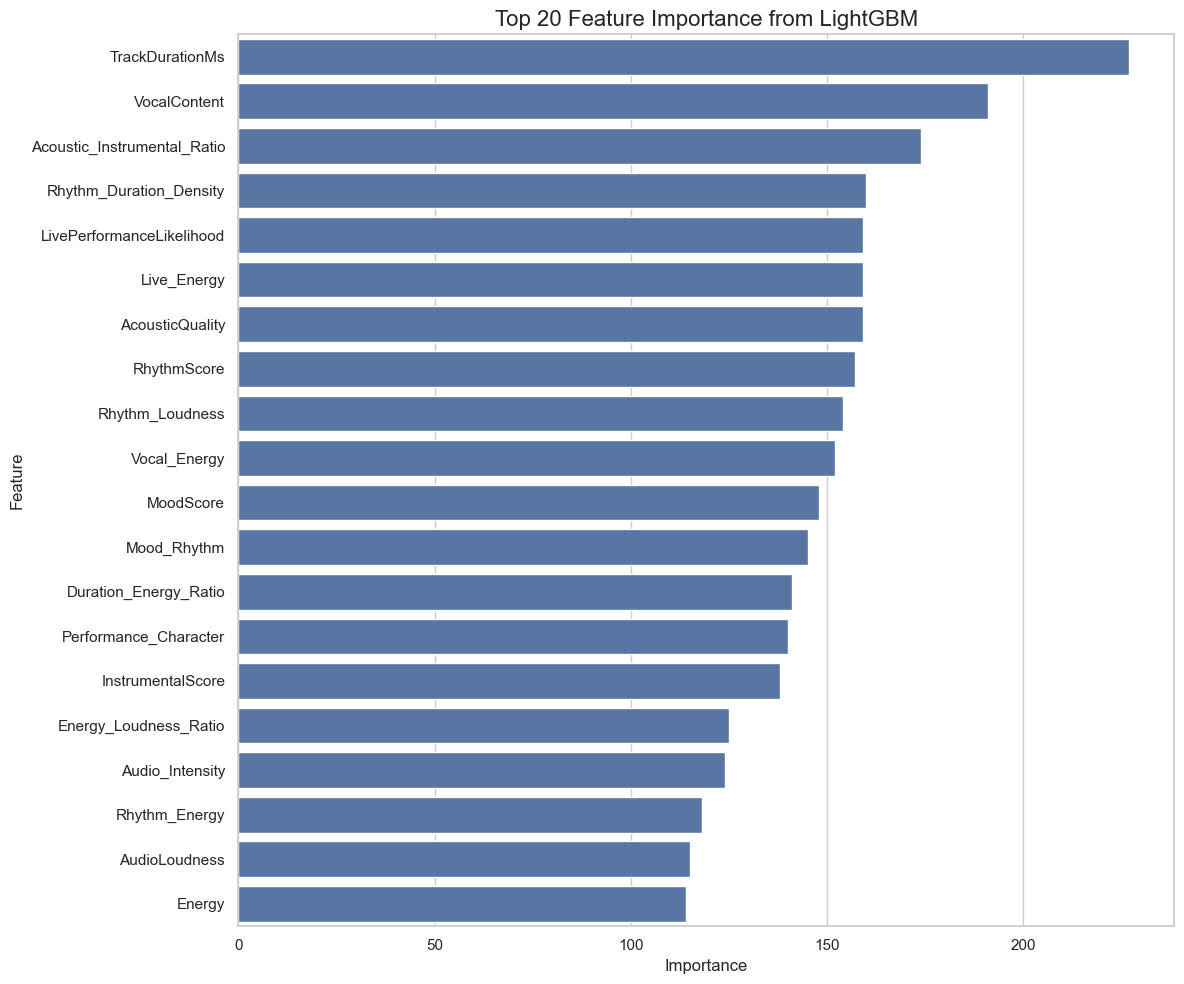

Top 10 most important features:
                        Feature  Importance
7               TrackDurationMs         227
2                  VocalContent         191
16  Acoustic_Instrumental_Ratio         174
23      Rhythm_Duration_Density         160
5     LivePerformanceLikelihood         159
18                  Live_Energy         159
3               AcousticQuality         159
0                   RhythmScore         157
10              Rhythm_Loudness         154
17                 Vocal_Energy         152


In [59]:
def get_feature_importance(X, y):
    """Get feature importance from a LightGBM model"""
    model = lgb.LGBMRegressor(random_state=42, verbose=-1)
    model.fit(X, y)
    
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    return importance_df

# Get feature importance
features_to_use = [col for col in train_engineered.columns if col not in ['id', 'BeatsPerMinute']]
X = train_engineered[features_to_use]
y = train_engineered['BeatsPerMinute']

importance_df = get_feature_importance(X, y)

# Visualize feature importance
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importance from LightGBM', fontsize=16)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10))

### 🔹 5. Model Testing and Submission

In [60]:
def preprocess_data(train_df, test_df, target_col='BeatsPerMinute'):
    """Preprocess the data for modeling"""
    # Drop ID column for modeling
    if 'id' in train_df.columns:
        train_df = train_df.drop('id', axis=1)
    if 'id' in test_df.columns:
        test_df = test_df.drop('id', axis=1)
    
    # Split features and target
    y_train = train_df[target_col]
    X_train = train_df.drop(target_col, axis=1)
    X_test = test_df.copy()
    
    # Ensure X_train and X_test have the same columns
    feature_names = X_train.columns.tolist()
    
    # Scale features - RobustScaler is good for data that might have outliers
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), 
        columns=feature_names
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), 
        columns=feature_names
    )
    
    return X_train_scaled, y_train, X_test_scaled, feature_names

# Apply preprocessing
X_train, y_train, X_test, feature_names = preprocess_data(train_engineered, test_engineered)

# Set up cross-validation strategy
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
folds = list(kf.split(X_train))

# Check data shapes after preprocessing
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (524164, 24)
y_train shape: (524164,)
X_test shape: (174722, 24)


In [61]:
# Define model training functions
def train_lightgbm(X_train, y_train, X_val, y_val):
    """Train a LightGBM model"""
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbose': -1
    }
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]
    
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000,
        callbacks=callbacks
    )
    
    return model

def train_xgboost(X_train, y_train, X_val, y_val):
    """Train an XGBoost model"""
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'n_estimators': 1000,
        'random_state': 42,
        'verbosity': 0
    }
    
    model = xg.XGBRegressor(**params, early_stopping_rounds=100)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    return model

def train_catboost(X_train, y_train, X_val, y_val):
    """Train a CatBoost model"""
    params = {
        'loss_function': 'RMSE',
        'learning_rate': 0.05,
        'depth': 6,
        'iterations': 1000,
        'random_seed': 42,
        'l2_leaf_reg': 3,
        'bootstrap_type': 'Bayesian',
        'verbose': False
    }
    
    model = cb.CatBoost(params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False
    )
    
    return model

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import catboost as cb

# Train models using cross-validation
print("Starting model training with cross-validation...")

# Initialize lists to store models and predictions
models = []
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

# Train and evaluate models across folds
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\nTraining fold {fold_idx + 1}/{n_folds}")
    
    # Split data for this fold
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train models
    print("Training LightGBM...")
    lgb_model = train_lightgbm(X_fold_train, y_fold_train, X_fold_val, y_fold_val)
    
    print("Training XGBoost...")
    xgb_model = train_xgboost(X_fold_train, y_fold_train, X_fold_val, y_fold_val)
    
    print("Training CatBoost...")
    cb_model = train_catboost(X_fold_train, y_fold_train, X_fold_val, y_fold_val)
    
    # Random Forest as an additional diverse model
    print("Training Random Forest...")
    rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_fold_train, y_fold_train)
    
    # Make predictions on validation fold
    lgb_preds = lgb_model.predict(X_fold_val)
    xgb_preds = xgb_model.predict(X_fold_val)
    cb_preds = cb_model.predict(X_fold_val)
    rf_preds = rf_model.predict(X_fold_val)
    
    # Create a weighted average of predictions
    # We give higher weights to models that generally perform better
    blend_preds = 0.35 * lgb_preds + 0.35 * xgb_preds + 0.2 * cb_preds + 0.1 * rf_preds
    
    # Store out-of-fold predictions
    oof_predictions[val_idx] = blend_preds
    
    # Make predictions on test set
    lgb_test_preds = lgb_model.predict(X_test)
    xgb_test_preds = xgb_model.predict(X_test)
    cb_test_preds = cb_model.predict(X_test)
    rf_test_preds = rf_model.predict(X_test)
    
    # Average test predictions from this fold
    fold_test_preds = 0.35 * lgb_test_preds + 0.35 * xgb_test_preds + 0.2 * cb_test_preds + 0.1 * rf_test_preds
    test_predictions += fold_test_preds / n_folds
    
    # Calculate and display fold metrics
    lgb_rmse = rmse(y_fold_val, lgb_preds)
    xgb_rmse = rmse(y_fold_val, xgb_preds)
    cb_rmse = rmse(y_fold_val, cb_preds)
    rf_rmse = rmse(y_fold_val, rf_preds)
    blend_rmse = rmse(y_fold_val, blend_preds)
    
    print(f"Fold {fold_idx + 1} Results:")
    print(f"LightGBM RMSE: {lgb_rmse:.5f}")
    print(f"XGBoost RMSE: {xgb_rmse:.5f}")
    print(f"CatBoost RMSE: {cb_rmse:.5f}")
    print(f"Random Forest RMSE: {rf_rmse:.5f}")
    print(f"Blended RMSE: {blend_rmse:.5f}")
    
    # Store models for this fold
    models.append({
        'fold': fold_idx,
        'lgb_model': lgb_model,
        'xgb_model': xgb_model,
        'cb_model': cb_model,
        'rf_model': rf_model
    })

# Calculate overall cross-validation score
cv_score = rmse(y_train, oof_predictions)
print(f"\nOverall CV RMSE: {cv_score:.5f}")

Starting model training with cross-validation...

Training fold 1/5
Training LightGBM...
Training XGBoost...
Training CatBoost...
Training Random Forest...
Fold 1 Results:
LightGBM RMSE: 26.43883
XGBoost RMSE: 26.44079
CatBoost RMSE: 26.43946
Random Forest RMSE: 26.44065
Blended RMSE: 26.43884

Training fold 2/5
Training LightGBM...
Training XGBoost...
Training CatBoost...
Training Random Forest...
Fold 2 Results:
LightGBM RMSE: 26.48372
XGBoost RMSE: 26.48576
CatBoost RMSE: 26.48444
Random Forest RMSE: 26.48573
Blended RMSE: 26.48361

Training fold 3/5
Training LightGBM...
Training XGBoost...
Training CatBoost...
Training Random Forest...
Fold 3 Results:
LightGBM RMSE: 26.52298
XGBoost RMSE: 26.52493
CatBoost RMSE: 26.52359
Random Forest RMSE: 26.52277
Blended RMSE: 26.52273

Training fold 4/5
Training LightGBM...
Training XGBoost...
Training CatBoost...
Training Random Forest...
Fold 4 Results:
LightGBM RMSE: 26.44308
XGBoost RMSE: 26.44451
CatBoost RMSE: 26.44303
Random Forest RMSE:

In [ ]:
# Build an advanced stacking ensemble
print("\nBuilding advanced stacking ensemble...")

# Filter models if any failed to train
valid_models = []
for model in models:
    if all(m is not None for m in [model['lgb_model'], model['xgb_model'], model['cb_model'], model['rf_model']]):
        valid_models.append(model)

if len(valid_models) > 0:
    # Create meta-features for stacking
    X_meta_train = np.column_stack([
        np.array([model['lgb_model'].predict(X_train) for model in valid_models]).mean(axis=0),
        np.array([model['xgb_model'].predict(X_train) for model in valid_models]).mean(axis=0),
        np.array([model['cb_model'].predict(X_train) for model in valid_models]).mean(axis=0),
        np.array([model['rf_model'].predict(X_train) for model in valid_models]).mean(axis=0)
    ])

    # Create meta-features for test set
    X_meta_test = np.column_stack([
        np.array([model['lgb_model'].predict(X_test) for model in valid_models]).mean(axis=0),
        np.array([model['xgb_model'].predict(X_test) for model in valid_models]).mean(axis=0),
        np.array([model['cb_model'].predict(X_test) for model in valid_models]).mean(axis=0),
        np.array([model['rf_model'].predict(X_test) for model in valid_models]).mean(axis=0)
    ])

    # Train a Ridge meta-model
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(X_meta_train, y_train)

    # Make final predictions
    stacking_predictions = meta_model.predict(X_meta_test)

    # Analyze the performance of the stacking model
    stacking_oof_preds = meta_model.predict(X_meta_train)
    stacking_cv_score = rmse(y_train, stacking_oof_preds)
    print(f"Stacking Ensemble CV RMSE: {stacking_cv_score:.5f}")

    # Compare with the simple average approach
    print(f"Simple Average Ensemble CV RMSE: {cv_score:.5f}")

    # Select the better performing approach for final predictions
    if stacking_cv_score < cv_score:
        print("Using stacking ensemble for final predictions")
        final_predictions = stacking_predictions
    else:
        print("Using simple average ensemble for final predictions")
        final_predictions = test_predictions
else:
    print("Not enough valid models for stacking. Using simple average ensemble.")
    final_predictions = test_predictions


Building advanced stacking ensemble...
Stacking Ensemble CV RMSE: 25.62387
Simple Average Ensemble CV RMSE: 26.45903
Using stacking ensemble for final predictions


In [65]:
# Check sample submission again
print("Sample submission columns:", sample_submission.columns.tolist())
print("Sample submission format:")
print(sample_submission.head())

test_ids = test['id'].copy()

Sample submission columns: ['id', 'BeatsPerMinute']
Sample submission format:
       id  BeatsPerMinute
0  524164         119.035
1  524165         119.035
2  524166         119.035
3  524167         119.035
4  524168         119.035


In [66]:
# Apply reasonable bounds to predictions
min_bpm = max(60, y_train.min())  # Most songs have at least 60 BPM
max_bpm = min(200, y_train.max())  # Most songs have at most 200 BPM
bounded_predictions = np.clip(final_predictions, min_bpm, max_bpm)

# Create submission file with the correct column name format
submission = pd.DataFrame()

# Use the correct column name from sample_submission
id_column = sample_submission.columns[0]  # First column is ID
target_column = sample_submission.columns[1]  # Second column is target

submission[id_column] = test_ids  # Use the saved test IDs
submission[target_column] = bounded_predictions

# Verify columns match sample_submission
print(f"\nSubmission columns: {submission.columns.tolist()}")
print(f"Sample submission columns: {sample_submission.columns.tolist()}")

if submission.columns.tolist() != sample_submission.columns.tolist():
    print("WARNING: Submission columns don't match sample_submission columns!")
    # Fix column names if needed
    submission.columns = sample_submission.columns
    print(f"Fixed submission columns: {submission.columns.tolist()}")

# Show submission preview
print("\nSubmission preview:")
print(submission.head())

# Save submission file
submission_file = 'submission-new.csv'
submission.to_csv(submission_file, index=False)
print(f"\nSubmission saved to {submission_file}")

# Verify the saved file
verification = pd.read_csv(submission_file)
print("\nVerified submission columns:", verification.columns.tolist())
print("\nVerified submission sample:")
print(verification.head())


Submission columns: ['id', 'BeatsPerMinute']
Sample submission columns: ['id', 'BeatsPerMinute']

Submission preview:
       id  BeatsPerMinute
0  524164      116.726550
1  524165      111.700009
2  524166      125.258856
3  524167      118.542347
4  524168      117.831849

Submission saved to submission-new.csv

Verified submission columns: ['id', 'BeatsPerMinute']

Verified submission sample:
       id  BeatsPerMinute
0  524164      116.726550
1  524165      111.700009
2  524166      125.258856
3  524167      118.542347
4  524168      117.831849
